# 02 - Baseline e estratégia adaptativa (Thompson Sampling)

**Problema:** para cada cliente, escolher como abordá-lo (canal e janela da semana) para maximizar a conversão.

| Elemento | Definição |
|---|---|
| Braços (4) | `celular_inicio_semana`, `celular_fim_semana`, `telefone_inicio_semana`, `telefone_fim_semana` |
| Contexto (36) | segmento etário (`jovem`, `adulto`, `senior`) x mês da campanha (`jan` a `dec`) |
| Recompensa | 1 se o cliente converteu, 0 se não |
| Prior | Beta(1, 1) em cada (contexto, braço): nenhuma preferência inicial, equivale a 1 sucesso e 1 falha fictícios |
| Posterior | Beta(1 + sucessos, 1 + falhas) |
| Decisão | sorteia uma taxa de cada Beta e escolhe o maior sorteio |

**Por que Thompson Sampling:** a exploração é proporcional à incerteza. Um braço com poucos dados tem uma Beta larga e
às vezes ganha o sorteio; um braço ruim com muitos dados quase nunca ganha. Não há hiperparâmetro de exploração para
ajustar (ao contrário do epsilon do Epsilon-Greedy), e o estado do modelo são só contadores, fáceis de auditar e de
atualizar em tempo real.

O código das políticas está em `src/bandit.py` e o da simulação em `src/simulation.py`. É o mesmo código que o
pipeline executa e registra no MLflow.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")
logging.getLogger("matplotlib").setLevel(logging.WARNING)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": INK_2,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "text.color": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.titlelocation": "left",
        "figure.dpi": 110,
    }
)

In [2]:
from src.config import DATA_PATH
from src.data_processing import _resolve_local_path, read_raw_csv

# Usa data/raw/train.csv; se não existir, baixa a base pública do Kaggle.
train_path = _resolve_local_path(DATA_PATH if Path(DATA_PATH).is_absolute() else str(ROOT / DATA_PATH))
raw = read_raw_csv(train_path)
raw["y"] = raw["y"].astype(str).str.lower().isin(["yes", "1"]).astype(int)
print(train_path, raw.shape)

from datetime import UTC, datetime

import numpy as np

# O módulo do pipeline configura o matplotlib para gerar arquivos; aqui voltamos ao modo inline.
from src.train_and_experiment import POLICY_COLORS, plot_curves, run_golden_set

%matplotlib inline

from src.data_processing import build_campaign_history, build_client_features, drop_unwanted_columns

clean = drop_unwanted_columns(raw)
data = build_campaign_history(clean).merge(
    build_client_features(clean, datetime.now(UTC))[["client_id", "customer_segment"]], on="client_id"
)
data.head()

/w/data/raw/train.csv (28645, 21)


2026-09-27 20:36:38,424 INFO Removendo colunas (vazamento/sensíveis/índice/macro): ['campaign', 'marital', 'default', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']


,client_id,arm,month,converted,customer_segment
0,1,celular_inicio_semana,nov,0,adulto
1,2,celular_fim_semana,nov,0,adulto
2,5,celular_inicio_semana,may,0,adulto
3,6,celular_fim_semana,jun,1,adulto
4,8,celular_inicio_semana,aug,0,adulto


## 1. Baseline: regra fixa

A política de controle é a mais simples possível: **sempre oferecer o braço de maior conversão histórica**, para todos
os clientes, o ano todo. É o que uma área de negócio faria olhando o relatório de campanhas passadas.

In [3]:
from src.config import ARM_NAMES

hist_rate = data.groupby("arm")["converted"].agg(contatos="size", conversao="mean").reindex(ARM_NAMES)
hist_rate["conversao_%"] = (100 * hist_rate.pop("conversao")).round(2)
baseline_arm = hist_rate["conversao_%"].idxmax()
print("Baseline = sempre", baseline_arm)
hist_rate

Baseline = sempre celular_fim_semana


,contatos,conversao_%
arm,,
celular_inicio_semana,10891,14.79
celular_fim_semana,7299,15.23
telefone_inicio_semana,6292,5.07
telefone_fim_semana,4163,5.79


Nos dados históricos, a regra fixa converte **15,23%** nos clientes em que ela foi de fato aplicada. Esse número
não serve para comparar com o bandit, porque cada cliente do histórico recebeu só uma abordagem: não sabemos o que
teria acontecido com a outra. Por isso a comparação é feita por simulação.

## 2. Metodologia de avaliação

1. **Histórico (30%)**: define as regras dos baselines e inicializa as contagens do Thompson Sampling e do
   Epsilon-Greedy (*warm start*). Todas as políticas partem da mesma informação.
2. **Fluxo (70%, 20.052 clientes)**: os clientes chegam um a um, **em ordem de calendário** (mês a mês, como numa
   campanha real). Cada política escolhe um braço e a conversão é sorteada com a taxa real observada nos dados para
   aquele contexto e braço. Contextos com poucos contatos são suavizados em direção à taxa do mês.
3. **Mesmos números aleatórios** para todas as políticas (*common random numbers*): se duas políticas escolhem o mesmo
   braço para o mesmo cliente, o resultado é o mesmo. A diferença entre elas vem só das escolhas.
4. **5 seeds** (42 a 46): a métrica é a média, com o desvio padrão e em quantos seeds o TS venceu.

Políticas comparadas:

| Política | Descrição |
|---|---|
| `thompson_sampling` | o modelo proposto |
| `epsilon_greedy` | referência adaptativa: 10% das vezes um braço aleatório, 90% o de maior média |
| `baseline_fixo` | **baseline do desafio**: sempre o melhor braço histórico |
| `baseline_segmentado` | regra congelada por contexto: o melhor braço histórico de cada (segmento, mês) |
| `teste_ab_uniforme` | divide os clientes igualmente entre os 4 braços, como num teste A/B contínuo |

In [4]:
from src.simulation import SimulationConfig, run_simulation, summarize_seeds

SEEDS = range(42, 47)
runs = [run_simulation(data, SimulationConfig(seed=seed)) for seed in SEEDS]
per_seed = summarize_seeds(runs)

ts = per_seed[per_seed["politica"] == "thompson_sampling"].set_index("seed")["conversao"]
table = per_seed.groupby("politica").agg(
    conversao_media=("conversao", "mean"),
    desvio=("conversao", "std"),
    conversoes=("conversoes", "mean"),
    regret=("regret", "mean"),
    escolhas_subotimas=("subotimas", "mean"),
)
table["lift_do_TS_%"] = 100 * (table.loc["thompson_sampling", "conversao_media"] / table["conversao_media"] - 1)
table["TS_vence_em"] = [
    "-"
    if name == "thompson_sampling"
    else f"{(ts > per_seed[per_seed['politica'] == name].set_index('seed')['conversao']).sum()}/{len(SEEDS)}"
    for name in table.index
]
table = table.sort_values("conversao_media", ascending=False)
display_table = table.copy()
for col in ["conversao_media", "desvio", "escolhas_subotimas"]:
    display_table[col] = (100 * display_table[col]).round(2)
display_table.round(2)

,conversao_media,desvio,conversoes,regret,escolhas_subotimas,lift_do_TS_%,TS_vence_em
politica,,,,,,,
baseline_segmentado,18.32,0.60,3672.8,165.71,31.01,-0.38,1/5
thompson_sampling,18.25,0.33,3658.8,180.16,34.32,0.00,-
epsilon_greedy,17.97,0.33,3604.0,232.73,33.91,1.52,4/5
baseline_fixo,17.46,0.39,3502.0,339.20,65.87,4.48,5/5
teste_ab_uniforme,12.93,0.23,2592.6,1239.86,75.02,41.12,5/5


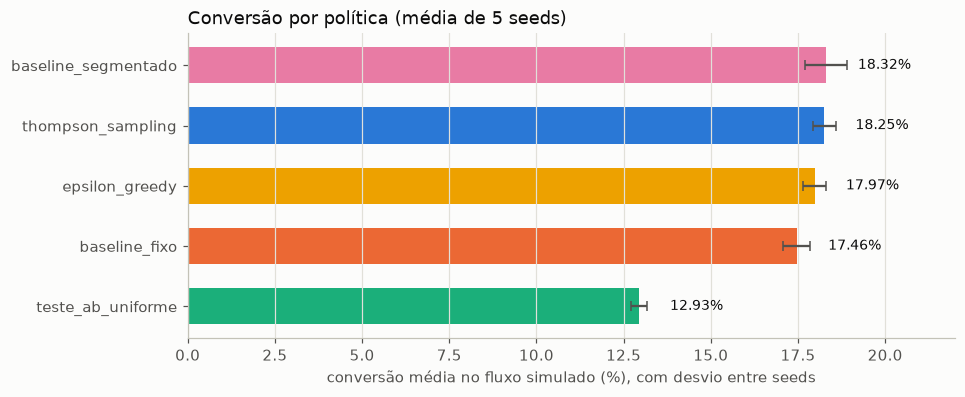

In [5]:
order = table.index[::-1]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.grid(axis="x", color=GRID)
ax.grid(axis="y", visible=False)
ax.barh(
    order,
    100 * table.loc[order, "conversao_media"],
    xerr=100 * table.loc[order, "desvio"],
    color=[POLICY_COLORS[n] for n in order],
    height=0.6,
    error_kw={"ecolor": INK_2, "capsize": 3},
)
for i, name in enumerate(order):
    v = 100 * table.loc[name, "conversao_media"]
    ax.text(v + 0.9, i, f"{v:.2f}%", va="center", fontsize=9, color=INK)
ax.set_xlim(0, 22)
ax.set_xlabel("conversão média no fluxo simulado (%), com desvio entre seeds")
ax.set_title("Conversão por política (média de 5 seeds)")
plt.show()

**Leitura dos resultados:**

- **O Thompson Sampling supera o baseline do desafio** (regra fixa) em todos os seeds, com cerca de +4,5% de conversão
  relativa: 0,79 ponto percentual, ou ~790 conversões a mais a cada 100 mil clientes abordados.
- Supera também o Epsilon-Greedy, que explora às cegas (sorteia qualquer braço 10% das vezes, inclusive os que já
  sabe que são ruins), e o teste A/B, com cerca de +41%.
- **Empata com o `baseline_segmentado`**. Essa regra é o "gabarito" de quem já tem um histórico completo de todos os
  contextos: ela precisa que alguém tenha testado os 4 braços em cada segmento e mês antes, ou seja, depende de um
  teste longo já concluído, e fica congelada depois. O TS chega ao mesmo nível aprendendo em produção e continua se
  ajustando se o comportamento mudar.
- A maior parte do ganho sobre a regra fixa vem do **contexto** (mês e segmento). O TS é a forma de explorar esse
  contexto de modo contínuo e com custo de exploração controlado.

## 3. Conversão acumulada ao longo do fluxo (seed 42)

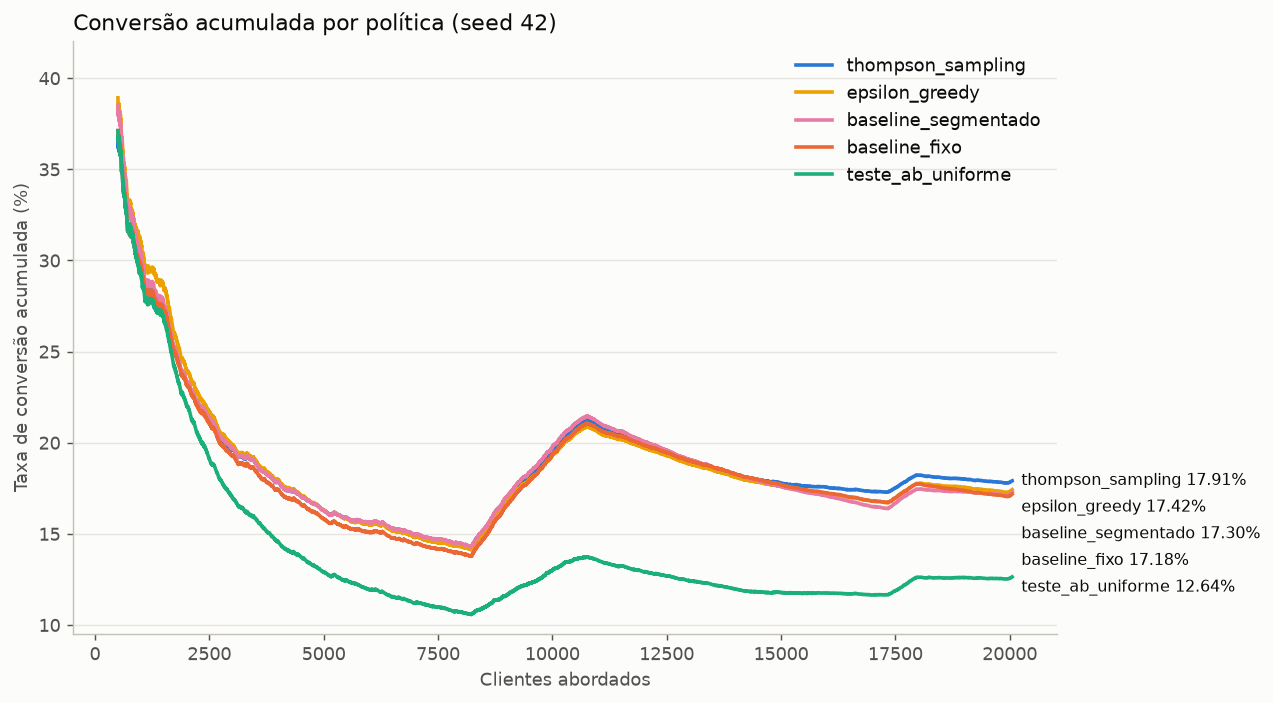

In [6]:
from IPython.display import Image

plot_curves(runs[0]["results"], Path("conversion_curves.png"), "Conversão acumulada por política (seed 42)")
img = Image("conversion_curves.png")
Path("conversion_curves.png").unlink()
img

As curvas refletem a ordem do calendário: a conversão sobe e desce conforme o mês (os primeiros clientes são de março,
com conversão alta). A separação mais visível acontece no fim do fluxo, em novembro: o melhor braço passa a ser o
telefone fixo, a regra fixa continua mandando todo mundo para o celular e o Thompson Sampling muda de braço.

## 4. Análise da exploração

Explorar tem custo: cada escolha fora do melhor braço do contexto é conversão esperada perdida (*regret*). A pergunta é
**onde** cada política paga esse custo. Abaixo, as conversões perdidas a cada 1.000 clientes, mês a mês, em relação a
escolher sempre o melhor braço de cada contexto (seed 42).

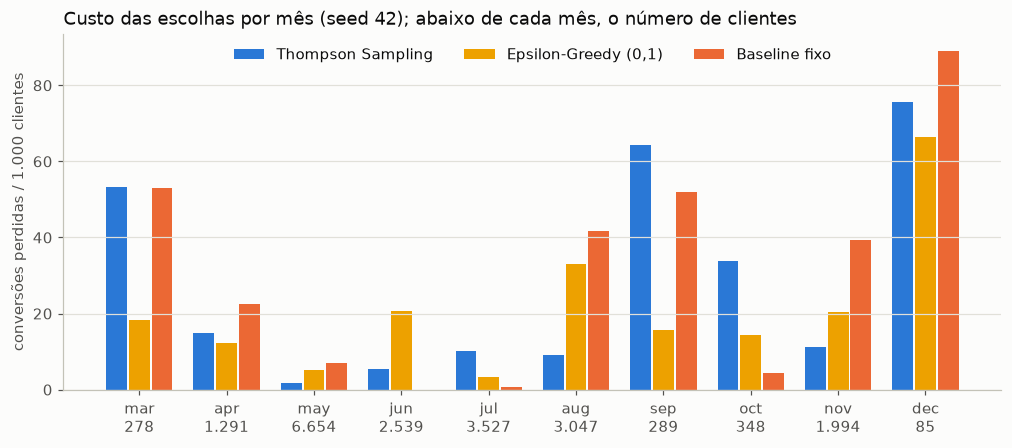

,thompson_sampling,epsilon_greedy,baseline_segmentado,baseline_fixo,clientes_no_mes
mar,53.3,18.3,31.7,53.1,278
apr,14.8,12.2,22.5,22.6,1291
may,1.7,5.2,0.7,6.9,6654
jun,5.4,20.5,0.0,0.0,2539
jul,10.2,3.2,12.9,0.6,3527
aug,9.2,33.1,57.4,41.8,3047
sep,64.4,15.7,0.7,52.0,289
oct,33.9,14.3,33.0,4.3,348
nov,11.2,20.4,6.0,39.2,1994
dec,75.7,66.4,0.0,89.1,85


Média ponderada no fluxo inteiro (conversões perdidas / 1.000 clientes):
thompson_sampling       9.09
epsilon_greedy         13.74
baseline_segmentado    14.29
baseline_fixo          16.04


In [7]:
stream = runs[0]["stream"]
rates = runs[0]["rates"]
contexts, stream_months = stream["context"].to_numpy(), stream["month"].to_numpy()
oracle = np.array([max(rates[(c, a)] for a in ARM_NAMES) for c in contexts])
month_order = list(pd.unique(stream_months))

lost = {}
for name in ["thompson_sampling", "epsilon_greedy", "baseline_segmentado", "baseline_fixo"]:
    chosen_rate = np.array([rates[(c, a)] for c, a in zip(contexts, runs[0]["results"][name]["chosen"], strict=True)])
    lost[name] = pd.Series(1000 * (oracle - chosen_rate)).groupby(stream_months).mean()
lost = pd.DataFrame(lost).reindex(month_order)
lost["clientes_no_mes"] = pd.Series(stream_months).value_counts()

shown = {
    "thompson_sampling": "Thompson Sampling",
    "epsilon_greedy": "Epsilon-Greedy (0,1)",
    "baseline_fixo": "Baseline fixo",
}
fig, ax = plt.subplots(figsize=(11, 4.2))
width = 0.26
x = np.arange(len(month_order))
for k, (name, label) in enumerate(shown.items()):
    ax.bar(x + (k - 1) * width, lost[name], width=width * 0.92, color=POLICY_COLORS[name], label=label)
ax.set_xticks(x, [f"{m}\n{n:,}".replace(",", ".") for m, n in zip(month_order, lost["clientes_no_mes"], strict=True)])
ax.set_ylabel("conversões perdidas / 1.000 clientes")
ax.set_title("Custo das escolhas por mês (seed 42); abaixo de cada mês, o número de clientes")
ax.legend(frameon=False, loc="upper center", ncol=3)
plt.show()

weights = lost["clientes_no_mes"]
total = lost.drop(columns="clientes_no_mes").mul(weights, axis=0).sum() / weights.sum()
display(lost.round(1))
print("Média ponderada no fluxo inteiro (conversões perdidas / 1.000 clientes):")
print(total.round(2).to_string())

In [8]:
ts_choices = pd.DataFrame({"month": stream_months, "arm": runs[0]["results"]["thompson_sampling"]["chosen"]})
share = pd.crosstab(ts_choices["month"], ts_choices["arm"], normalize="index")
share = share.reindex(index=month_order, columns=ARM_NAMES)
share = (100 * share).round(1)
# Melhor braço do mês ponderado pelos clientes de cada contexto no fluxo.
share["melhor_braco_no_mes"] = [
    max(ARM_NAMES, key=lambda a: np.mean([rates[(c, a)] for c in contexts[stream_months == m]])) for m in share.index
]
share

arm,celular_inicio_semana,celular_fim_semana,telefone_inicio_semana,telefone_fim_semana,melhor_braco_no_mes
month,,,,,
mar,34.2,16.2,15.8,33.8,celular_inicio_semana
apr,8.8,32.8,9.0,49.4,telefone_inicio_semana
may,80.0,19.9,0.1,0.1,celular_inicio_semana
jun,16.7,83.3,0.0,0.0,celular_fim_semana
jul,13.9,72.3,10.1,3.7,celular_fim_semana
aug,10.4,4.1,76.6,8.9,telefone_inicio_semana
sep,66.8,12.1,3.5,17.6,celular_inicio_semana
oct,20.7,33.3,21.6,24.4,celular_fim_semana
nov,2.6,4.6,33.2,59.6,telefone_fim_semana


- **Baseline fixo:** custo zero em junho e julho, quando a regra acerta, e alto em abril, agosto e novembro, quando
  o melhor braço é o telefone fixo e a regra continua no celular. Ele nunca corrige esse erro.
- **Epsilon-Greedy:** tem um piso de custo que não some (junho, por exemplo), porque 10% das escolhas são sempre
  aleatórias, mesmo quando a resposta já é conhecida.
- **Thompson Sampling:** custo baixo nos meses com muitos dados (maio, agosto, novembro), onde tem certeza. Ele paga
  mais nos meses com poucos contatos (março, setembro, outubro, dezembro), onde os contextos têm poucos dados e ele
  ainda está testando. Somando o fluxo inteiro, é a política com menor custo nesta seed.
- A tabela de escolhas confirma o comportamento: em 9 dos 10 meses, a maior fatia das escolhas do TS vai para o braço
  que é de fato o melhor naquele mês. A exceção é abril, em que os dois braços de telefone estão praticamente empatados.

## 5. Sem histórico (*cold start*)

E se não houvesse histórico? O TS e o Epsilon-Greedy começam do prior Beta(1, 1), enquanto os baselines continuam
usando os 30% de histórico (vantagem para eles).

In [9]:
cold = summarize_seeds([run_simulation(data, SimulationConfig(seed=s, cold_start=True)) for s in SEEDS])
cold_table = cold.groupby("politica")["conversao"].agg(["mean", "std"]).mul(100).round(2)
cold_table.columns = ["conversao_media_%", "desvio"]
cold_table.sort_values("conversao_media_%", ascending=False)

,conversao_media_%,desvio
politica,,
baseline_segmentado,18.32,0.60
epsilon_greedy,17.84,0.22
thompson_sampling,17.69,0.12
baseline_fixo,17.46,0.39
teste_ab_uniforme,12.93,0.23


Partindo do zero, o Thompson Sampling ainda supera a regra fixa, que usou o histórico, e fica muito acima do teste
A/B. Nesse cenário o Epsilon-Greedy fica um pouco à frente: com 36 contextos e nenhum dado, o TS explora mais no
começo (cada Beta(1, 1) é totalmente incerta). É um custo pago uma vez: com o warm start, a ordem se inverte.

## 6. Golden Set: 5 clientes de teste

Cinco clientes fictícios (ids 900001 a 900005, fora da faixa do dataset), cada um num mês de campanha. A **oferta
recomendada** é o sorteio do TS (muda de uma chamada para outra); o **melhor braço do modelo** é o de maior conversão
esperada no posterior; o **melhor braço nos dados** é o de maior taxa real no contexto. A decisão faz sentido quando os
dois últimos coincidem.

In [10]:
golden = run_golden_set(runs[0]["policies"]["thompson_sampling"], runs[0]["rates"])
golden

,client_id,idade,profissao,poutcome,contexto,oferta_recomendada,melhor_braco_modelo,conversao_esperada_%,melhor_braco_nos_dados,faz_sentido
0,900001,24,student,nonexistent,jovem|may,celular_inicio_semana,celular_inicio_semana,14.96,celular_inicio_semana,sim
1,900002,41,admin.,nonexistent,adulto|aug,celular_fim_semana,telefone_inicio_semana,13.54,telefone_inicio_semana,sim
2,900003,67,retired,success,senior|may,celular_inicio_semana,celular_inicio_semana,34.62,celular_inicio_semana,sim
3,900004,35,blue-collar,nonexistent,adulto|nov,telefone_inicio_semana,telefone_fim_semana,12.91,telefone_fim_semana,sim
4,900005,29,technician,failure,jovem|sep,celular_inicio_semana,celular_inicio_semana,47.83,celular_fim_semana,não


- **900001** (jovem, maio) e **900003** (senior, maio): celular no início da semana, o melhor braço de maio para esses
  segmentos. Em maio o volume é alto e o modelo tem certeza.
- **900002** (adulto, agosto): o braço que o modelo considera melhor é o **telefone fixo** no início da semana, o
  mesmo dos dados. Uma regra fixa mandaria celular. Neste sorteio específico o TS escolheu `celular_fim_semana`:
  é a exploração funcionando, e acontece numa fração pequena das chamadas.
- **900004** (adulto, novembro): o melhor braço do modelo e dos dados é o telefone no fim da semana, de novo diferente da
  regra fixa. O sorteio desta execução caiu no telefone no início da semana, braço próximo em novembro.
- **900005** (jovem, setembro): o modelo ainda acha que o melhor é celular no início da semana, mas nos dados é celular no
  fim da semana. Setembro tem poucos contatos de jovens e os dois braços estão próximos: o modelo ainda não tem certeza,
  e é exatamente por isso que o TS continua testando os dois nesse contexto. Com mais feedback, a escolha converge.

## Conclusão

- O Thompson Sampling com contexto (segmento x mês) **supera o baseline de regra fixa em todos os seeds** (~+4,5%), o
  Epsilon-Greedy e o teste A/B (~+41%).
- Ele empata com uma regra por contexto já calibrada, mas sem precisar de um teste longo antes, e continua aprendendo.
- Os mesmos resultados são registrados no MLflow pelo pipeline (`src/train_and_experiment.py`), com parâmetros,
  métricas por política, o gráfico e o Golden Set como artefatos.